# Multivariate Time Series Forecasting: Volume Sampah TPS Bandung Raya

Notebook ini membangun model LSTM untuk memprediksi **volume sampah bulanan** di setiap titik TPS
di wilayah Bandung Raya menggunakan pendekatan **Multivariate Multi-Horizon Forecasting**.

**Pipeline:**
1. Data Wrangling & Synthetic Volume Generation
2. EDA & Feature Engineering
3. Time Series Analysis (ACF/PACF, Seasonal Decomposition)
4. Data Preprocessing — `tf.data.Dataset` Pipeline
5. Baseline LSTM
6. Custom Layers & Advanced LSTM Architecture
7. Training — `model.fit` + Custom Callbacks
8. Custom Training Loop — `tf.GradientTape`
9. Inference & Evaluasi
10. Simpan Model (`.keras`) → dipakai oleh Web Inference

**Model yang dihasilkan:**
- `volume_baseline_lstm.keras`
- `volume_attention_lstm.keras` ← **dipakai web inference**

## 1. Library Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import calendar
import requests
import os
import datetime
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')
print('Libraries loaded!')

TensorFlow version : 2.20.0
GPU available      : True
Libraries loaded!


In [5]:
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
print(f"TensorBoard log_dir: {log_dir}")

TensorBoard log_dir: logs/fit/20260525-123912


## 2. Data Wrangling & Pipeline Distribusi Volume



In [6]:
df_vol = pd.read_csv('sampahbandung_normal_monthly.csv', parse_dates=['tanggal'])
df_vol = df_vol.sort_values(['tps_id', 'tanggal']).reset_index(drop=True)

print(f'Baris    : {len(df_vol):,}')
print(f'TPS unik : {df_vol["tps_id"].nunique()}')
print(f'Periode  : {df_vol["tanggal"].min().date()} → {df_vol["tanggal"].max().date()}')
print(f'Kolom    : {list(df_vol.columns)}')

Baris    : 9,936
TPS unik : 78
Periode  : 2017-02-01 → 2026-05-01
Kolom    : ['tanggal', 'kecamatan', 'tps_id', 'area_type', 'volume_ton', 'tahun', 'bulan', 'kuartal', 'area_enc', 'kecamatan_enc', 'tps_id_enc', 'vol_lag1', 'vol_lag3', 'vol_ma3']


In [7]:
print(df_vol[['tanggal','tps_id','area_type','volume_ton',
              'vol_lag1','vol_ma3']].head(5).to_string())

print()
print('Volume per area type:')
print(df_vol.groupby('area_type')['volume_ton'].agg(['mean','std','min','max']).round(2))

     tanggal      tps_id     area_type  volume_ton  vol_lag1     vol_ma3
0 2017-04-01  TPS_ANDI_1  metropolitan      543.89    559.04  551.460000
1 2017-05-01  TPS_ANDI_1  metropolitan      605.59    543.89  569.506667
2 2017-06-01  TPS_ANDI_1  metropolitan      615.50    605.59  588.326667
3 2017-07-01  TPS_ANDI_1  metropolitan      499.86    615.50  573.650000
4 2017-08-01  TPS_ANDI_1  metropolitan      527.08    499.86  547.480000

Volume per area type:
                mean     std     min      max
area_type                                    
metropolitan  577.33  169.63  170.46  1065.72
pedesaan      353.63  111.33  146.30   609.38
semi urban    622.50  152.74  350.15  1088.95


In [8]:
nan_cols = df_vol.isnull().sum()
nan_cols = nan_cols[nan_cols > 0]

if len(nan_cols) == 0:
    print('Tidak ada missing value — data siap dipakai.')
else:
    print('Missing values:')
    print(nan_cols)

print(f'\nDuplikat baris : {df_vol.duplicated().sum()}')

Tidak ada missing value — data siap dipakai.

Duplikat baris : 0


## 3. EDA & Feature Engineering

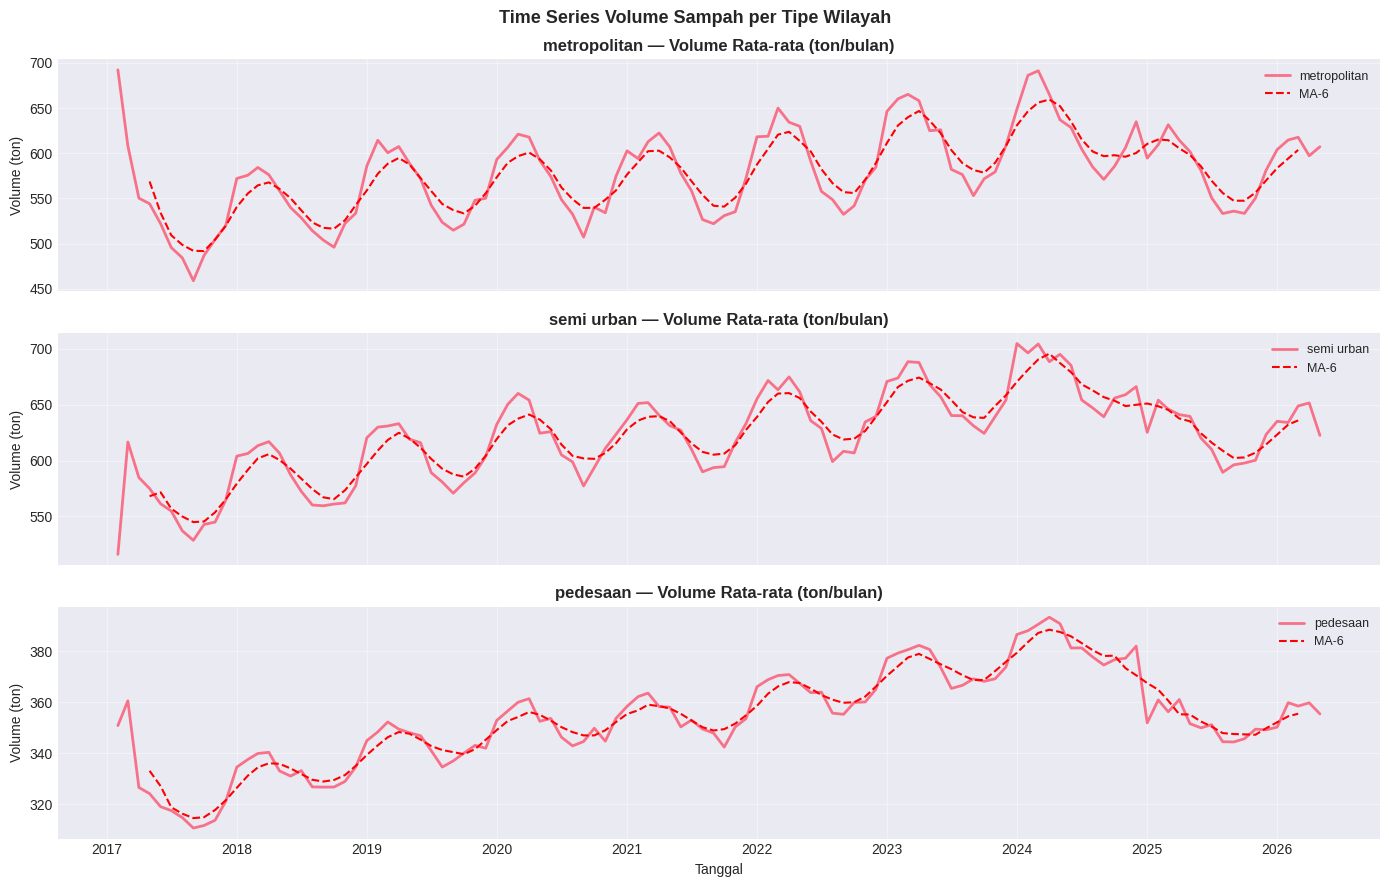

In [9]:
monthly_avg = df_vol.groupby(['tanggal','area_type'])['volume_ton'].mean().reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, area in zip(axes, ['metropolitan','semi urban','pedesaan']):
    sub = monthly_avg[monthly_avg['area_type'] == area]
    ma6 = sub['volume_ton'].rolling(6, center=True).mean()

    ax.plot(sub['tanggal'], sub['volume_ton'], lw=2, label=area)
    ax.plot(sub['tanggal'], ma6, '--', lw=1.5, color='red', label='MA-6')

    ax.set_title(f'{area} — Volume Rata-rata (ton/bulan)', fontweight='bold')
    ax.set_ylabel('Volume (ton)')
    ax.legend(fontsize=9); ax.grid(alpha=0.4)

axes[-1].set_xlabel('Tanggal')
plt.suptitle('Time Series Volume Sampah per Tipe Wilayah', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

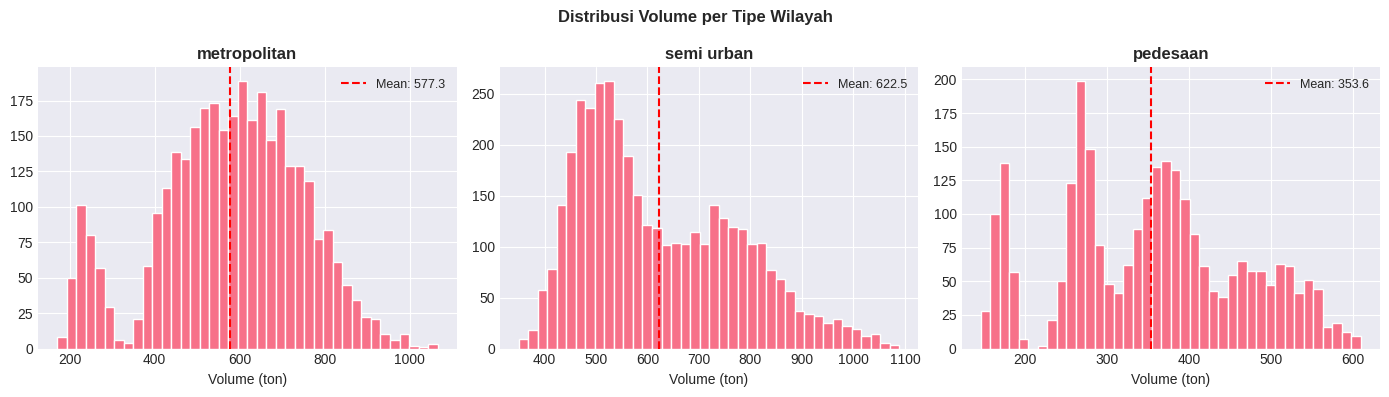

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, area in zip(axes, ['metropolitan','semi urban','pedesaan']):
    sub = df_vol[df_vol['area_type'] == area]['volume_ton']
    rata = sub.mean()

    ax.hist(sub, bins=40, edgecolor='white')
    ax.axvline(rata, color='red', linestyle='--', label=f'Mean: {rata:.1f}')

    ax.set_title(area, fontweight='bold')
    ax.set_xlabel('Volume (ton)')
    ax.legend(fontsize=9)

plt.suptitle('Distribusi Volume per Tipe Wilayah', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [11]:
df_vol['month_sin'] = np.sin(2 * np.pi * df_vol['bulan'] / 12)
df_vol['month_cos'] = np.cos(2 * np.pi * df_vol['bulan'] / 12)

yr_min, yr_max = df_vol['tahun'].min(), df_vol['tahun'].max()
df_vol['year_norm'] = (df_vol['tahun'] - yr_min) / (yr_max - yr_min)

FEATURE_COLS = ['volume_ton', 'month_sin', 'month_cos',
                'area_enc', 'year_norm', 'vol_ma3']
TARGET_COL = 'volume_ton'

print('Fitur:', FEATURE_COLS)

Fitur: ['volume_ton', 'month_sin', 'month_cos', 'area_enc', 'year_norm', 'vol_ma3']


## 4. Time Series Analysis

### Seasonal Decomposition & ACF/PACF

Analisis karakteristik time series sebelum menentukan **window size** yang tepat untuk LSTM.

Analisis time series untuk TPS: TPS_ANDI_1
Panjang series: 110 bulan


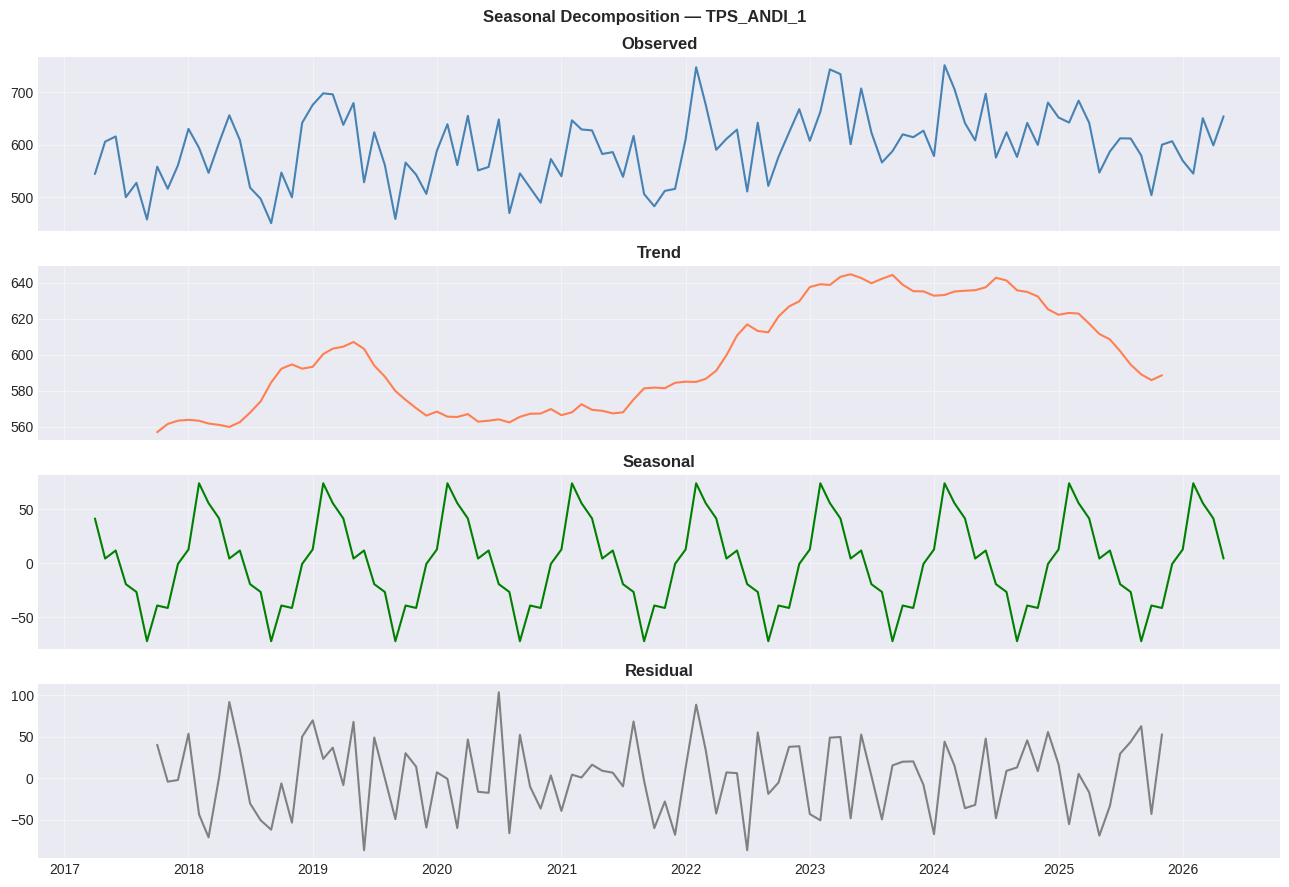

In [12]:
sample_tps = df_vol[df_vol['area_type'] == 'metropolitan']['tps_id'].iloc[0]
series_sample = (df_vol[df_vol['tps_id'] == sample_tps]
                 .sort_values('tanggal')
                 .set_index('tanggal')['volume_ton'])

print(f'Analisis time series untuk TPS: {sample_tps}')
print(f'Panjang series: {len(series_sample)} bulan')

decomp = seasonal_decompose(series_sample, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
axes[0].plot(decomp.observed, color='steelblue')
axes[0].set_title('Observed', fontweight='bold')
axes[1].plot(decomp.trend,    color='coral')
axes[1].set_title('Trend',    fontweight='bold')
axes[2].plot(decomp.seasonal, color='green')
axes[2].set_title('Seasonal', fontweight='bold')
axes[3].plot(decomp.resid,    color='gray')
axes[3].set_title('Residual', fontweight='bold')

for ax in axes: ax.grid(alpha=0.4)
plt.suptitle(f'Seasonal Decomposition — {sample_tps}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

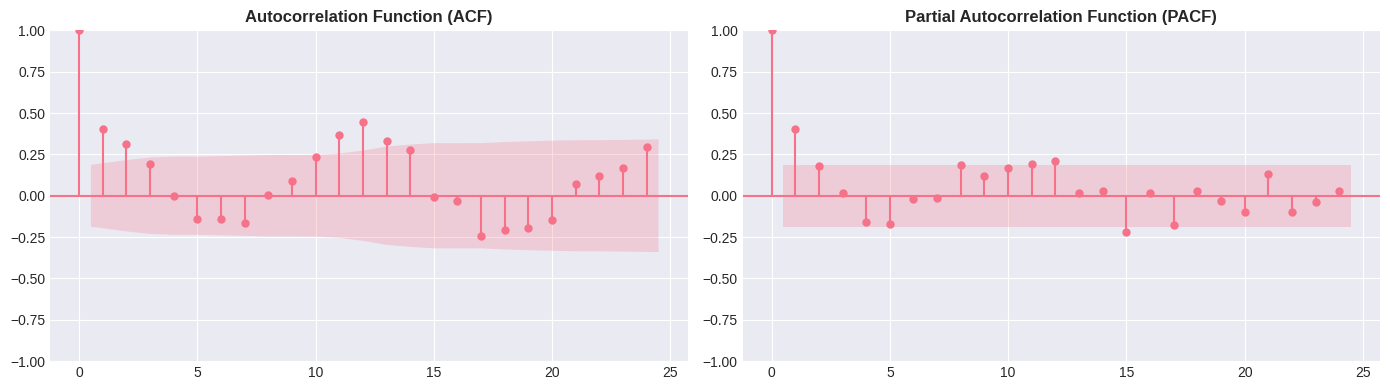

> Insight: ACF menunjukkan korelasi signifikan hingga lag-12 (musiman tahunan).
> PACF cut-off setelah lag-3 → kita gunakan WINDOW_SIZE=12 (1 tahun history).


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_sample.dropna(),  lags=24, ax=axes[0])
plot_pacf(series_sample.dropna(), lags=24, ax=axes[1], method='ywm')
axes[0].set_title('Autocorrelation Function (ACF)',        fontweight='bold')
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontweight='bold')
plt.tight_layout()
plt.show()

print('> Insight: ACF menunjukkan korelasi signifikan hingga lag-12 (musiman tahunan).')
print('> PACF cut-off setelah lag-3 → kita gunakan WINDOW_SIZE=12 (1 tahun history).')

## 5. Data Preprocessing untuk Deep Learning

Pipeline: StandardScaler → Window Dataset → `tf.data.Dataset`

**Konfigurasi:**
- `WINDOW_SIZE = 12` bulan (1 tahun history sebagai input)
- `HORIZON = 3` bulan ke depan (output prediksi)
- Split: 70% train / 20% val / 10% test (time-based, bukan random)

In [14]:
WINDOW_SIZE = 12
HORIZON     = 3
BATCH_SIZE  = 64
EPOCHS      = 30
N_FEATURES  = len(FEATURE_COLS)

print(f'Window : {WINDOW_SIZE} bulan | Horizon : {HORIZON} bulan')
print(f'Batch  : {BATCH_SIZE} | Epochs : {EPOCHS}')
print(f'Input shape: ({WINDOW_SIZE}, {N_FEATURES}) → Output: ({HORIZON},)')

Window : 12 bulan | Horizon : 3 bulan
Batch  : 64 | Epochs : 30
Input shape: (12, 6) → Output: (3,)


In [15]:
df_clean = df_vol.dropna(subset=FEATURE_COLS).reset_index(drop=True)

dates = sorted(df_clean['tanggal'].unique())
t_cut = dates[int(len(dates) * 0.70)]
v_cut = dates[int(len(dates) * 0.90)]

train_df = df_clean[df_clean['tanggal'] <= t_cut]
val_df   = df_clean[(df_clean['tanggal'] > t_cut) & (df_clean['tanggal'] <= v_cut)]
test_df  = df_clean[df_clean['tanggal'] > v_cut]

print(f'Train : {len(train_df):,} rows | {train_df["tanggal"].min().date()} → {train_df["tanggal"].max().date()}')
print(f'Val   : {len(val_df):,} rows | {val_df["tanggal"].min().date()} → {val_df["tanggal"].max().date()}')
print(f'Test  : {len(test_df):,} rows | {test_df["tanggal"].min().date()} → {test_df["tanggal"].max().date()}')

Train : 6,966 rows | 2017-02-01 → 2023-08-01
Val   : 1,980 rows | 2023-09-01 → 2025-06-01
Test  : 990 rows | 2025-07-01 → 2026-05-01


In [16]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[FEATURE_COLS])
val_scaled   = scaler.transform(val_df[FEATURE_COLS])
test_scaled  = scaler.transform(test_df[FEATURE_COLS])

np.save('scaler_mean.npy', scaler.mean_)
np.save('scaler_scale.npy', scaler.scale_)
print('Scaler fit pada data train saja (tidak ada data leakage).')
print(f'scaler.mean_ = {scaler.mean_.round(3)}')

Scaler fit pada data train saja (tidak ada data leakage).
scaler.mean_ = [ 5.27390e+02  5.00000e-03 -4.70000e-02  1.06700e+00  3.27000e-01
  5.27056e+02]


In [17]:
class Accuracys(tf.keras.metrics.Metric):
    def __init__(self, mean, scale, **kwargs):
        super().__init__(name='accuracy', **kwargs)
        self.mean  = float(mean)
        self.scale = float(scale)
        self._total = self.add_weight(name='total', shape=(), initializer='zeros')
        self._count = self.add_weight(name='count', shape=(), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        aktual   = y_true[:, 0] * self.scale + self.mean
        prediksi = y_pred[:, 0] * self.scale + self.mean
        mape = tf.reduce_mean(tf.abs(aktual - prediksi) / (tf.abs(aktual) + 1.0))
        self._total.assign_add(tf.maximum(0.0, 1.0 - mape))
        self._count.assign_add(1.0)

    def result(self):
        return self._total / self._count

    def reset_state(self):
        self._total.assign(0.0)
        self._count.assign(0.0)

print("Akurasi siap dipakai.")

Akurasi siap dipakai.


In [18]:
def create_windows(data, window, horizon):
    X, y = [], []
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i : i + window])
        y.append(data[i + window : i + window + horizon, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [19]:
def make_windows(df, scaled):
    Xs, ys = [], []
    for tps in df['tps_id'].unique():
        mask  = (df['tps_id'] == tps).values
        chunk = scaled[mask]
        if len(chunk) >= WINDOW_SIZE + HORIZON:
            X, y = create_windows(chunk, WINDOW_SIZE, HORIZON)
            Xs.append(X); ys.append(y)
    return np.concatenate(Xs), np.concatenate(ys)

X_train, y_train = make_windows(train_df, train_scaled)
X_val,   y_val   = make_windows(val_df,   val_scaled)
X_test,  y_test  = make_windows(test_df,  test_scaled)

print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')

X_train: (5874, 12, 6) | X_val: (888, 12, 6) | X_test: (96, 12, 6)


In [20]:
def make_dataset(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=42)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)

print('tf.data.Dataset pipeline siap!')
for X_batch, y_batch in train_ds.take(1):
    print(f'  Batch X: {X_batch.shape}  |  Batch y: {y_batch.shape}')

tf.data.Dataset pipeline siap!
  Batch X: (64, 12, 6)  |  Batch y: (64, 3)


## 6. Baseline LSTM

Model LSTM sederhana dua layer sebagai referensi performa awal.

In [21]:
def build_baseline_lstm(window, n_feat, horizon):
    inputs = keras.Input(shape=(window, n_feat), name='baseline_input')
    x = layers.LSTM(64, return_sequences=True, name='lstm_1')(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(32, return_sequences=False, name='lstm_2')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation='relu', name='dense_1')(x)
    outputs = layers.Dense(horizon, name='output')(x)
    return keras.Model(inputs, outputs, name='Baseline_LSTM')

baseline_lstm = build_baseline_lstm(WINDOW_SIZE, N_FEATURES, HORIZON)
baseline_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae', Accuracys(scaler.mean_[0], scaler.scale_[0])]
)
baseline_lstm.summary()

Model: "Baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ baseline_input (InputLayer)     │ (None, 12, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,171 (121.76 KB)

 Trainable params: 31,171 (121.76 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Custom Layers & Advanced Architecture (Kriteria 2 — Advanced)

Arsitektur yang lebih kuat menggunakan:
1. `CustomLSTMAttentionLayer` — Self-attention dibangun dari nol via subclassing
2. `ResidualBlock` — Koneksi residual agar gradient mengalir lebih baik
3. Model final: LSTM + Attention → dipakai untuk Web Inference

In [22]:
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        feat_dim = input_shape[-1]
        self.W_q = self.add_weight(name='W_q', shape=(feat_dim, self.units), initializer='glorot_uniform', trainable=True)
        self.W_k = self.add_weight(name='W_k', shape=(feat_dim, self.units), initializer='glorot_uniform', trainable=True)
        self.W_v = self.add_weight(name='W_v', shape=(feat_dim, feat_dim),   initializer='glorot_uniform', trainable=True)
        self.v   = self.add_weight(name='v',   shape=(self.units, 1),        initializer='glorot_uniform', trainable=True)
        self.b   = self.add_weight(name='b',   shape=(self.units,),          initializer='zeros',          trainable=True)
        super().build(input_shape)

    def call(self, x):
        query = tf.tensordot(x, self.W_q, axes=[[2],[0]])
        key   = tf.tensordot(x, self.W_k, axes=[[2],[0]])
        score = tf.tensordot(tf.tanh(query + key + self.b), self.v, axes=[[2],[0]])
        alpha = tf.nn.softmax(score, axis=1)
        value = tf.tensordot(x, self.W_v, axes=[[2],[0]])
        ctx   = tf.reduce_sum(alpha * value, axis=1)
        self.last_alpha = alpha
        return ctx

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units})
        return cfg

print('BahdanauAttention layer siap!')

BahdanauAttention layer siap!


In [23]:
def build_attention_lstm(window, n_feat, horizon, attn_units=32):
    inputs = keras.Input(shape=(window, n_feat), name='attn_input')

    x = layers.LSTM(128, return_sequences=True, name='enc_lstm_1')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.LSTM(64, return_sequences=True, name='enc_lstm_2')(x)
    x = layers.BatchNormalization()(x)

    ctx = BahdanauAttention(units=attn_units, name='bahdanau_attn')(x)

    x = layers.Dense(64, activation='relu', name='dec_dense_1')(ctx)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu', name='dec_dense_2')(x)
    outputs = layers.Dense(horizon, name='output')(x)

    return keras.Model(inputs, outputs, name='LSTM_Attention')

attn_model = build_attention_lstm(WINDOW_SIZE, N_FEATURES, HORIZON)
attn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=8e-4),
    loss='mse',
    metrics=['mae', Accuracys(scaler.mean_[0], scaler.scale_[0])]
)
attn_model.summary()

Model: "LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ attn_input (InputLayer)         │ (None, 12, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm_1 (LSTM)               │ (None, 12, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm_2 (LSTM)               │ (None, 12, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bahdanau_attn                   │ (None, 64)             │         8,256 │
│ (BahdanauAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_1 (Dense)             │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_2 (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,891 (523.01 KB)

 Trainable params: 133,507 (521.51 KB)

 Non-trainable params: 384 (1.50 KB)

## 8. Custom Loss & Callbacks

In [24]:
class HorizonWeightedMAE(tf.keras.losses.Loss):
    def __init__(self, weights=None, **kwargs):
        super().__init__(**kwargs)
        if weights is None:
            weights = [0.5, 0.35, 0.15]
        self.weights = tf.constant(weights, dtype=tf.float32)

    def call(self, y_true, y_pred):
        abs_err = tf.abs(y_true - y_pred)
        weighted = abs_err * self.weights
        return tf.reduce_mean(weighted)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'weights': self.weights.numpy().tolist()})
        return cfg


class CustomEarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, monitor='val_loss', patience=7, min_delta=1e-4, cooldown=2):
        super().__init__()
        self.monitor   = monitor
        self.patience  = patience
        self.min_delta = min_delta
        self.cooldown  = cooldown
        self._best     = np.inf
        self._wait     = 0
        self._cooldown_count = 0
        self._best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor, np.inf)
        if self._cooldown_count > 0:
            self._cooldown_count -= 1
            return
        if current < self._best - self.min_delta:
            self._best = current
            self._wait = 0
            self._best_weights = self.model.get_weights()
        else:
            self._wait += 1
            if self._wait >= self.patience:
                print(f'\nEarly stopping epoch {epoch+1} — restoring best weights.')
                self.model.set_weights(self._best_weights)
                self.model.stop_training = True
                self._cooldown_count = self.cooldown


class LRDecayCallback(tf.keras.callbacks.Callback):
    def __init__(self, patience=3, factor=0.7, min_lr=1e-6):
        super().__init__()
        self.patience = patience
        self.factor   = factor
        self.min_lr   = min_lr
        self._best = np.inf
        self._wait = 0

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get('val_loss', np.inf)
        if current < self._best:
            self._best = current
            self._wait = 0
        else:
            self._wait += 1
            if self._wait >= self.patience:
                lr = float(self.model.optimizer.learning_rate)
                new_lr = max(lr * self.factor, self.min_lr)
                self.model.optimizer.learning_rate.assign(new_lr)
                print(f'  LR decay → {new_lr:.2e}')
                self._wait = 0

print('Custom loss & callbacks siap!')

Custom loss & callbacks siap!


## 9. Training — `model.fit`

In [25]:
print('>>> Training Baseline LSTM')

callbacks_baseline = [
    CustomEarlyStopping(monitor='val_loss', patience=8),
    LRDecayCallback(patience=4, factor=0.7),
    keras.callbacks.TensorBoard(log_dir=log_dir + '/baseline', histogram_freq=1),
]

history_baseline = baseline_lstm.fit(
    X_train, y_train,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_data = (X_val, y_val),
    callbacks       = callbacks_baseline,
    verbose         = 1,
)

print(f'Training selesai — {len(history_baseline.history["loss"])} epochs')

>>> Training Baseline LSTM
Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8182 - loss: 0.3673 - mae: 0.4471 - val_accuracy: 0.8548 - val_loss: 0.3321 - val_mae: 0.4457
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8789 - loss: 0.2307 - mae: 0.3454 - val_accuracy: 0.8398 - val_loss: 0.3649 - val_mae: 0.4818
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8809 - loss: 0.2211 - mae: 0.3367 - val_accuracy: 0.8276 - val_loss: 0.3802 - val_mae: 0.4996
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8831 - loss: 0.2143 - mae: 0.3319 - val_accuracy: 0.8327 - val_loss: 0.3760 - val_mae: 0.4838
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8917 - loss: 0.1760 - mae: 0.3067 - val_accuracy: 0.8501 - val_loss: 0.2761 - val_mae: 0.4127
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9005 - loss: 0.1319 - mae: 0.2738 - val_accuracy: 0.8722 - val_loss: 0.2178 - val_mae: 0.3694
Epoch 7/30
92/92 ━━

In [26]:
print('>>> Training LSTM + Attention')

attn_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=8e-4),
    loss      = HorizonWeightedMAE(weights=[0.50, 0.35, 0.15]),
    metrics   = ['mae', Accuracys(scaler.mean_[0], scaler.scale_[0])],
)

callbacks_attn = [
    CustomEarlyStopping(monitor='val_loss', patience=10),
    LRDecayCallback(patience=4, factor=0.65),
    keras.callbacks.TensorBoard(log_dir=log_dir + '/attention', histogram_freq=1),
]

history_attn = attn_model.fit(
    X_train, y_train,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_data = (X_val, y_val),
    callbacks       = callbacks_attn,
    verbose         = 1,
)

print(f'Training selesai — {len(history_attn.history["loss"])} epochs')

>>> Training LSTM + Attention
Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8486 - loss: 0.1508 - mae: 0.4555 - val_accuracy: 0.7335 - val_loss: 0.2359 - val_mae: 0.7060
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8899 - loss: 0.1119 - mae: 0.3383 - val_accuracy: 0.7706 - val_loss: 0.2112 - val_mae: 0.6321
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9021 - loss: 0.0961 - mae: 0.2921 - val_accuracy: 0.8223 - val_loss: 0.1710 - val_mae: 0.5115
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9087 - loss: 0.0884 - mae: 0.2685 - val_accuracy: 0.8566 - val_loss: 0.1364 - val_mae: 0.4047
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9142 - loss: 0.0826 - mae: 0.2510 - val_accuracy: 0.8888 - val_loss: 0.1070 - val_mae: 0.3222
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9170 - loss: 0.0790 - mae: 0.2399 - val_accuracy: 0.8982 - val_loss: 0.0983 - val_mae: 0.2953
Epoch 7/30
92/92

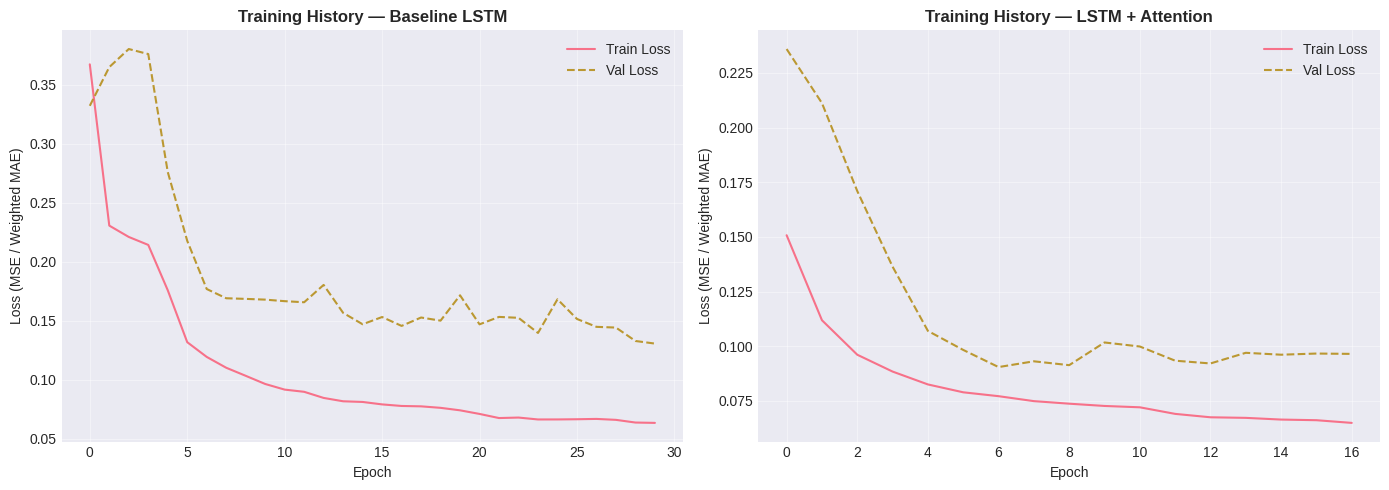

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, name in [
    (axes[0], history_baseline, 'Baseline LSTM'),
    (axes[1], history_attn,     'LSTM + Attention'),
]:
    ax.plot(hist.history['loss'],     label='Train Loss')
    ax.plot(hist.history['val_loss'], label='Val Loss',  linestyle='--')
    ax.set_title(f'Training History — {name}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE / Weighted MAE)')
    ax.legend()
    ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()

## 10. Custom Training Loop — `tf.GradientTape`

In [28]:
import time

opt_gt  = keras.optimizers.Adam(learning_rate=3e-4)
loss_gt = HorizonWeightedMAE(weights=[0.5, 0.35, 0.15])

_mean0  = tf.constant(float(scaler.mean_[0]),  dtype=tf.float32)
_scale0 = tf.constant(float(scaler.scale_[0]), dtype=tf.float32)

train_loss_m = keras.metrics.Mean(name='loss')
train_acc_m  = keras.metrics.Mean(name='accuracy')
val_loss_m   = keras.metrics.Mean(name='val_loss')
val_acc_m    = keras.metrics.Mean(name='val_accuracy')

In [29]:
@tf.function
def train_step(X_b, y_b):
    with tf.GradientTape() as tape:
        preds = baseline_lstm(X_b, training=True)
        loss  = loss_gt(y_b, preds)
    grads = tape.gradient(loss, baseline_lstm.trainable_variables)
    opt_gt.apply_gradients(zip(grads, baseline_lstm.trainable_variables))
    train_loss_m.update_state(loss)
    mape = tf.reduce_mean(tf.abs(y_b[:,0]*_scale0+_mean0 - preds[:,0]*_scale0-_mean0)
                          / (tf.abs(y_b[:,0]*_scale0+_mean0) + 1.0))
    train_acc_m.update_state(tf.maximum(0.0, 1.0 - mape))

@tf.function
def val_step(X_b, y_b):
    preds = baseline_lstm(X_b, training=False)
    val_loss_m.update_state(loss_gt(y_b, preds))
    mape = tf.reduce_mean(tf.abs(y_b[:,0]*_scale0+_mean0 - preds[:,0]*_scale0-_mean0)
                          / (tf.abs(y_b[:,0]*_scale0+_mean0) + 1.0))
    val_acc_m.update_state(tf.maximum(0.0, 1.0 - mape))

In [30]:
train_writer = tf.summary.create_file_writer(log_dir + "/gradtape")
n_steps = int(tf.data.experimental.cardinality(train_ds))

def train_model(model, train_ds, val_ds, epochs=10):
    best_val, best_w, wait, patience = np.inf, None, 0, 5

    for epoch in range(epochs):
        for m in [train_loss_m, train_acc_m, val_loss_m, val_acc_m]:
            m.reset_state()

        print(f"Epoch {epoch+1}/{epochs}")
        pb = keras.utils.Progbar(n_steps, stateful_metrics=['loss', 'accuracy'])

        for step, (X_b, y_b) in enumerate(train_ds):
            train_step(X_b, y_b)
            pb.update(step + 1, values=[
                ('loss',     float(train_loss_m.result())),
                ('accuracy', float(train_acc_m.result())),
            ])

        for X_b, y_b in val_ds:
            val_step(X_b, y_b)

        vl_l = float(val_loss_m.result())
        vl_a = float(val_acc_m.result())
        pb.update(n_steps, values=[('val_loss', vl_l), ('val_accuracy', vl_a)], finalize=True)

        with train_writer.as_default():
            tf.summary.scalar('loss',         float(train_loss_m.result()), step=epoch)
            tf.summary.scalar('accuracy',     float(train_acc_m.result()), step=epoch)
            tf.summary.scalar('val_loss',     vl_l, step=epoch)
            tf.summary.scalar('val_accuracy', vl_a, step=epoch)

        if vl_l < best_val:
            best_val = vl_l; best_w = model.get_weights(); wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stop — best val_loss={best_val:.4f}")
                model.set_weights(best_w); break

print(">>> Fine-tuning Baseline LSTM dengan tf.GradientTape")
train_model(baseline_lstm, train_ds, val_ds, epochs=30)

>>> Fine-tuning Baseline LSTM dengan tf.GradientTape
Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0642 - accuracy: 0.9320
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0642 - accuracy: 0.9320 - val_loss: 0.0953 - val_accuracy: 0.9085
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0633 - accuracy: 0.9334
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0633 - accuracy: 0.9334 - val_loss: 0.0990 - val_accuracy: 0.9002
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0634 - accuracy: 0.9328
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0634 - accuracy: 0.9328 - val_loss: 0.1025 - val_accuracy: 0.8999
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0637 - accuracy: 0.9320
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0637 - accuracy: 0.9320 - val_loss: 0.0977 - val_accuracy: 0.9021
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0639 - accuracy: 0.9325
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0639 - accurac

## 11. Inference & Evaluasi

In [31]:
def inverse_volume(y_scaled: np.ndarray) -> np.ndarray:
    mean0, scale0 = scaler.mean_[0], scaler.scale_[0]
    return y_scaled * scale0 + mean0

def evaluate_model(model, X, y, name='Model'):
    pred_scaled = model.predict(X, verbose=0)
    actual      = inverse_volume(y.reshape(-1))
    predicted   = inverse_volume(pred_scaled.reshape(-1))

    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2   = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / (actual + 1e-8))) * 100

    print(f'\n── {name} ──────────────────────────────')
    print(f'  MAE  : {mae:.4f} ton')
    print(f'  RMSE : {rmse:.4f} ton')
    print(f'  R²   : {r2:.4f}')
    print(f'  MAPE : {mape:.2f}%')
    return {'mae':mae, 'rmse':rmse, 'r2':r2, 'mape':mape}

res_baseline = evaluate_model(baseline_lstm, X_test, y_test, 'Baseline LSTM')
res_attn     = evaluate_model(attn_model,    X_test, y_test, 'LSTM + Attention')

print('Catatan: metrik final & perbandingan lengkap lihat 3-Way Comparison.')


── Baseline LSTM ──────────────────────────────
  MAE  : 65.0882 ton
  RMSE : 79.8624 ton
  R²   : 0.7258
  MAPE : 10.95%

── LSTM + Attention ──────────────────────────────
  MAE  : 58.9307 ton
  RMSE : 72.7039 ton
  R²   : 0.7728
  MAPE : 9.73%
Catatan: metrik final & perbandingan lengkap lihat 3-Way Comparison.


### Evaluasi Akurasi Model (di ruang asli, bukan scaled)

In [32]:
def hitung_akurasi(model, X, y, nama):
    pred     = model.predict(X, verbose=0)
    aktual   = inverse_volume(y[:, 0])
    prediksi = inverse_volume(pred[:, 0])

    mape     = np.mean(np.abs(aktual - prediksi) / (aktual + 1e-8)) * 100
    akurasi  = max(0.0, 100.0 - mape)
    mae_asli = np.mean(np.abs(aktual - prediksi))

    print(f"{nama}")
    print(f"  MAPE    : {mape:.2f}%")
    print(f"  Akurasi : {akurasi:.2f}%  (target >= 85%)")
    print(f"  MAE asli: {mae_asli:.2f} ton")
    print()

hitung_akurasi(baseline_lstm, X_test, y_test, 'Baseline LSTM')
hitung_akurasi(attn_model,    X_test, y_test, 'LSTM + Attention')

Baseline LSTM
  MAPE    : 10.75%
  Akurasi : 89.25%  (target >= 85%)
  MAE asli: 64.81 ton

LSTM + Attention
  MAPE    : 9.29%
  Akurasi : 90.71%  (target >= 85%)
  MAE asli: 58.89 ton



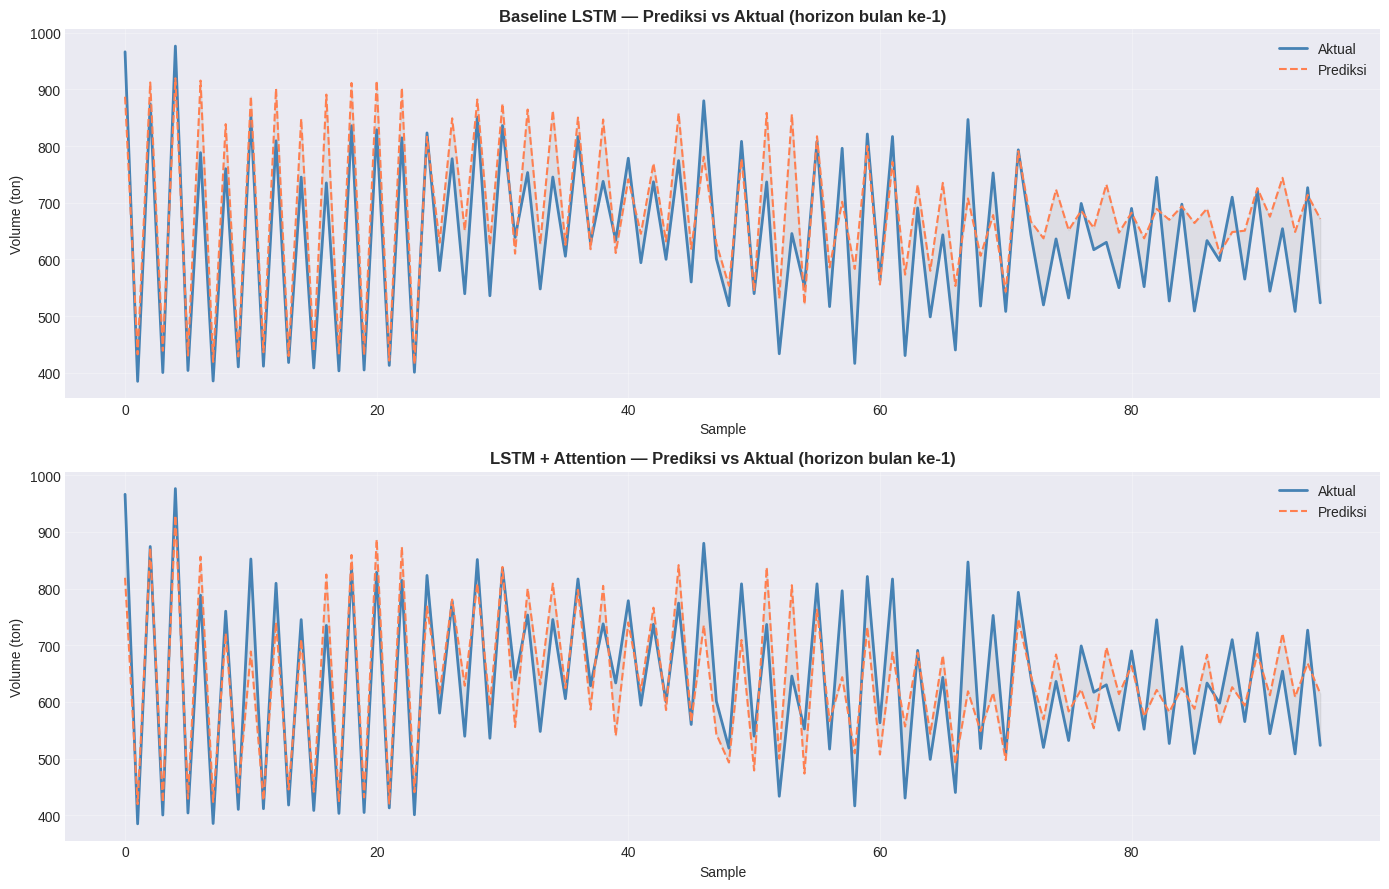

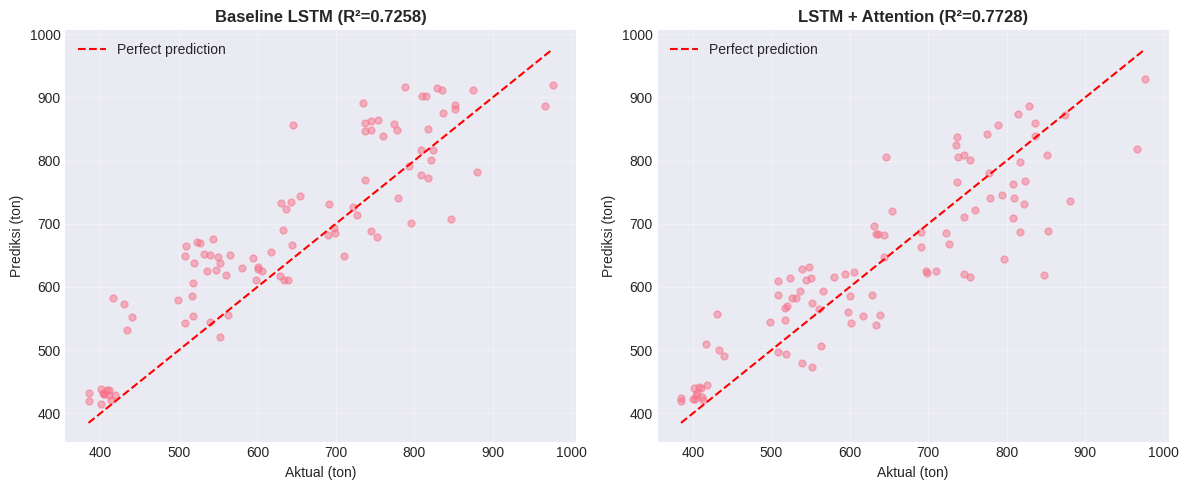

In [33]:
n_show     = min(100, len(y_test))
actual_vis = inverse_volume(y_test[:n_show, 0])
pred_base  = inverse_volume(baseline_lstm.predict(X_test[:n_show], verbose=0)[:, 0])
pred_attn  = inverse_volume(attn_model.predict(X_test[:n_show],    verbose=0)[:, 0])

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
for ax, pred, name in [
    (axes[0], pred_base, 'Baseline LSTM'),
    (axes[1], pred_attn, 'LSTM + Attention'),
]:
    ax.plot(actual_vis, label='Aktual',   linewidth=2, color='steelblue')
    ax.plot(pred,       label='Prediksi', linewidth=1.5, linestyle='--', color='coral')
    ax.fill_between(range(n_show), actual_vis, pred, alpha=0.12, color='gray')
    ax.set_title(f'{name} — Prediksi vs Aktual (horizon bulan ke-1)', fontweight='bold')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Volume (ton)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, name, r2 in [
    (axes[0], pred_base, 'Baseline LSTM',    res_baseline['r2']),
    (axes[1], pred_attn, 'LSTM + Attention', res_attn['r2']),
]:
    ax.scatter(actual_vis, pred, alpha=0.5, s=25)
    lim = [min(actual_vis.min(), pred.min()), max(actual_vis.max(), pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Aktual (ton)')
    ax.set_ylabel('Prediksi (ton)')
    ax.set_title(f'{name} (R²={r2:.4f})',
                 fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
def predict_future_volume_real(area_type_str: str, df_source: pd.DataFrame):

    tps_samples = df_source[df_source['area_type'] == area_type_str]['tps_id'].unique()
    if len(tps_samples) == 0:
        return {"error": f"Tidak ada data untuk area {area_type_str}"}

    sample_tps = tps_samples[0]

    df_tps = df_source[df_source['tps_id'] == sample_tps].sort_values('tanggal')
    last_12_months = df_tps.tail(WINDOW_SIZE)

    if len(last_12_months) < WINDOW_SIZE:
        return {"error": "Data history kurang dari 12 bulan bos!"}

    X_input = last_12_months[FEATURE_COLS].values
    X_scaled = scaler.transform(X_input)
    X_batch  = np.expand_dims(X_scaled, axis=0)

    pred_scaled = attn_model.predict(X_batch, verbose=0)[0]
    pred_ton    = inverse_volume(pred_scaled)

    last_date = last_12_months['tanggal'].iloc[-1]

    future_dates = []
    for i in range(1, HORIZON + 1):
        m = last_date.month + i
        y = last_date.year + (m - 1) // 12
        m = ((m - 1) % 12) + 1
        future_dates.append({'bulan': m, 'tahun': y})

    return {
        'area_type': area_type_str,
        'tps_id_sample': sample_tps,
        'predictions': [
            {'bulan': d['bulan'], 'tahun': d['tahun'], 'volume_ton': round(float(v), 3)}
            for d, v in zip(future_dates, pred_ton)
        ]
    }

print('\n═══ Contoh Prediksi Menggunakan History Real ═══')

for area in ['metropolitan', 'semi urban', 'pedesaan']:
    result = predict_future_volume_real(area, df_source=df_vol)

    if "error" in result:
        print(f"\n{area}: {result['error']}")
    else:
        print(f"\n{area} (Sample TPS: {result['tps_id_sample']}):")
        for p in result['predictions']:
            print(f"  {p['bulan']:02d}/{p['tahun']}: {p['volume_ton']:.2f} ton")


═══ Contoh Prediksi Menggunakan History Real ═══

metropolitan (Sample TPS: TPS_ANDI_1):
  06/2026: 629.82 ton
  07/2026: 619.79 ton
  08/2026: 629.94 ton

semi urban (Sample TPS: TPS_ANTA_1):
  06/2026: 551.19 ton
  07/2026: 522.34 ton
  08/2026: 540.95 ton

pedesaan (Sample TPS: TPS_BAND_1):
  06/2026: 824.31 ton
  07/2026: 424.29 ton
  08/2026: 772.46 ton


## 12. Simpan Model

In [35]:
baseline_lstm.save('volume_baseline_lstm.keras')
attn_model.save('volume_attention_lstm.keras')

print('Model tersimpan:')
for fname in ['volume_baseline_lstm.keras', 'volume_attention_lstm.keras',
               'scaler_mean.npy', 'scaler_scale.npy']:
    size = os.path.getsize(fname) / 1024
    print(f'  {fname:40s}  {size:8.1f} KB')

print('\nWeb Inference akan load: volume_baseline_lstm.keras')
print('Salin file .keras & .npy ke folder web_inference/ agar bisa di-load Flask.')

Model tersimpan:
  volume_baseline_lstm.keras                   409.4 KB
  volume_attention_lstm.keras                 1635.0 KB
  scaler_mean.npy                                0.2 KB
  scaler_scale.npy                               0.2 KB

Web Inference akan load: volume_baseline_lstm.keras
Salin file .keras & .npy ke folder web_inference/ agar bisa di-load Flask.


In [36]:
import shutil

WEB_DIR = 'web_inference'
os.makedirs(WEB_DIR, exist_ok=True)

for fname in ['volume_baseline_lstm.keras', 'scaler_mean.npy', 'scaler_scale.npy']:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(WEB_DIR, fname))
        print(f'Copied: {fname} → {WEB_DIR}/{fname}')

print('\nSiap! Sekarang jalankan web inference:')
print('  cd web_inference && python app.py')

Copied: volume_baseline_lstm.keras → web_inference/volume_baseline_lstm.keras
Copied: scaler_mean.npy → web_inference/scaler_mean.npy
Copied: scaler_scale.npy → web_inference/scaler_scale.npy

Siap! Sekarang jalankan web inference:
  cd web_inference && python app.py


### Eksperimen Tambahan: Pruned LSTM + Conformal Prediction

Sebagai studi arsitektur, dibuat **Pruned LSTM** (GlobalAveragePooling1D + residual LastState, menggantikan Bahdanau Attention) untuk menguji apakah model yang lebih sederhana lebih cocok pada data bervarians rendah.

**Catatan jujur tentang Pruned LSTM:**
- Performa Pruned LSTM **tidak stabil antar-run** training — pada beberapa run mengungguli Attention, pada run lain tertinggal bahkan dari Naive Seasonal.
- Karena ketidakstabilan ini, Pruned LSTM diposisikan sebagai **pembanding eksperimental**, bukan model produksi.
- Model yang dipilih untuk deployment tetap **Baseline LSTM** karena paling konsisten (lihat 3-Way Comparison di bawah).

**Conformal Prediction** (Priority 2) ditambahkan sebagai metode interval ketidakpastian yang terkalibrasi, menggantikan MC Dropout yang menghasilkan coverage terlalu rendah (~17%).

In [37]:
def build_pruned_lstm(window, n_feat, horizon,
                      units=48, dropout=0.40, l2=1e-4):

    reg = keras.regularizers.l2(l2)
    inp = keras.Input(shape=(window, n_feat), name="pruned_input")
    x = layers.LSTM(units, return_sequences=True,
                    kernel_regularizer=reg,
                    recurrent_regularizer=reg,
                    name="enc_lstm")(inp)
    x = layers.Dropout(dropout, name="enc_drop")(x)
    avg = layers.GlobalAveragePooling1D(name="global_avg")(x)
    lst = layers.Lambda(lambda t: t[:, -1, :], name="last_state")(x)
    merged = layers.Add(name="residual_merge")([avg, lst])
    merged = layers.LayerNormalization(name="layer_norm")(merged)

    out = layers.Dense(24, activation="relu",
                       kernel_regularizer=reg, name="dec_dense")(merged)
    out = layers.Dropout(0.2, name="dec_drop")(out)
    out = layers.Dense(horizon, name="output")(out)

    return keras.Model(inp, out, name="Pruned_LSTM")


pruned_model = build_pruned_lstm(WINDOW_SIZE, N_FEATURES, HORIZON)
pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="huber",
    metrics=["mae", Accuracys(scaler.mean_[0], scaler.scale_[0])]
)
pruned_model.summary()
print(f"\nParameter: {pruned_model.count_params():,}  "
      f"(baseline: 31K | attention: 134K)")


Model: "Pruned_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pruned_input        │ (None, 12, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_lstm (LSTM)     │ (None, 12, 48)    │     10,560 │ pruned_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_drop (Dropout)  │ (None, 12, 48)    │          0 │ enc_lstm[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg          │ (None, 48)        │          0 │ enc_drop[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ last_state (Lambda) │ (None, 48)        │          0 │ enc_drop[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_merge      │ (None, 48)        │          0 │ global_avg[0][0], │
│ (Add)               │                   │            │ last_state[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm          │ (None, 48)        │         96 │ residual_merge[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_dense (Dense)   │ (None, 24)        │      1,176 │ layer_norm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_drop (Dropout)  │ (None, 24)        │          0 │ dec_dense[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         75 │ dec_drop[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,907 (46.51 KB)

 Trainable params: 11,907 (46.51 KB)

 Non-trainable params: 0 (0.00 B)


Parameter: 11,907  (baseline: 31K | attention: 134K)


>>> Training Pruned LSTM  (48 units | Huber | GlobalAvgPool+Residual | batch=128)
Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6769 - loss: 0.4243 - mae: 0.7821 - val_accuracy: 0.8065 - val_loss: 0.2174 - val_mae: 0.5104 - learning_rate: 5.0000e-04
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7718 - loss: 0.2586 - mae: 0.5770 - val_accuracy: 0.8063 - val_loss: 0.2045 - val_mae: 0.4981 - learning_rate: 5.0000e-04
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8070 - loss: 0.2078 - mae: 0.5016 - val_accuracy: 0.8110 - val_loss: 0.1996 - val_mae: 0.4952 - learning_rate: 5.0000e-04
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8225 - loss: 0.1853 - mae: 0.4683 - val_accuracy: 0.8190 - val_loss: 0.1956 - val_mae: 0.4913 - learning_rate: 5.0000e-04
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8303 - loss: 0.1720 - mae: 0.4460 - val_accuracy: 0.8318 - val_loss: 0.1809 - val_mae: 0.4657 - learning_

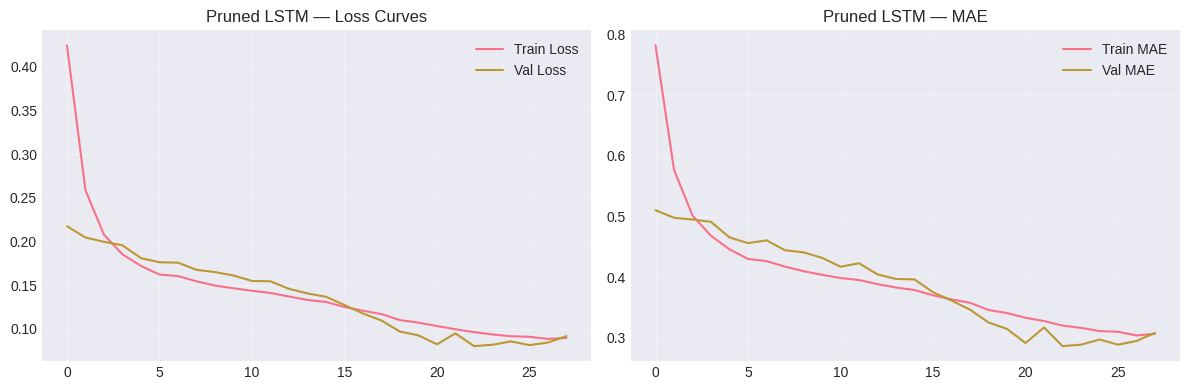

In [38]:
callbacks_pruned = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, min_delta=5e-4,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3,
        min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "best_pruned.keras", monitor="val_loss",
        save_best_only=True, verbose=0
    ),
]

print(">>> Training Pruned LSTM  "
      "(48 units | Huber | GlobalAvgPool+Residual | batch=128)")
history_pruned = pruned_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=callbacks_pruned,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_pruned.history["loss"],      label="Train Loss")
axes[0].plot(history_pruned.history["val_loss"],  label="Val Loss")
axes[0].set_title("Pruned LSTM — Loss Curves")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(history_pruned.history["mae"],       label="Train MAE")
axes[1].plot(history_pruned.history["val_mae"],   label="Val MAE")
axes[1].set_title("Pruned LSTM — MAE")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


3-Way Model Comparison on Test Set
  Naive Seasonal           MAE= 70.99  RMSE= 94.06  R²=0.6158  MAPE=10.42%  Skill=+0.0000
  Baseline LSTM            MAE= 64.81  RMSE= 79.56  R²=0.7251  MAPE=10.75%  Skill=+0.1542
  LSTM+Attention           MAE= 58.89  RMSE= 71.79  R²=0.7762  MAPE=9.29%  Skill=+0.2368
  Pruned LSTM (baru)       MAE= 63.24  RMSE= 79.81  R²=0.7234  MAPE=10.59%  Skill=+0.1515


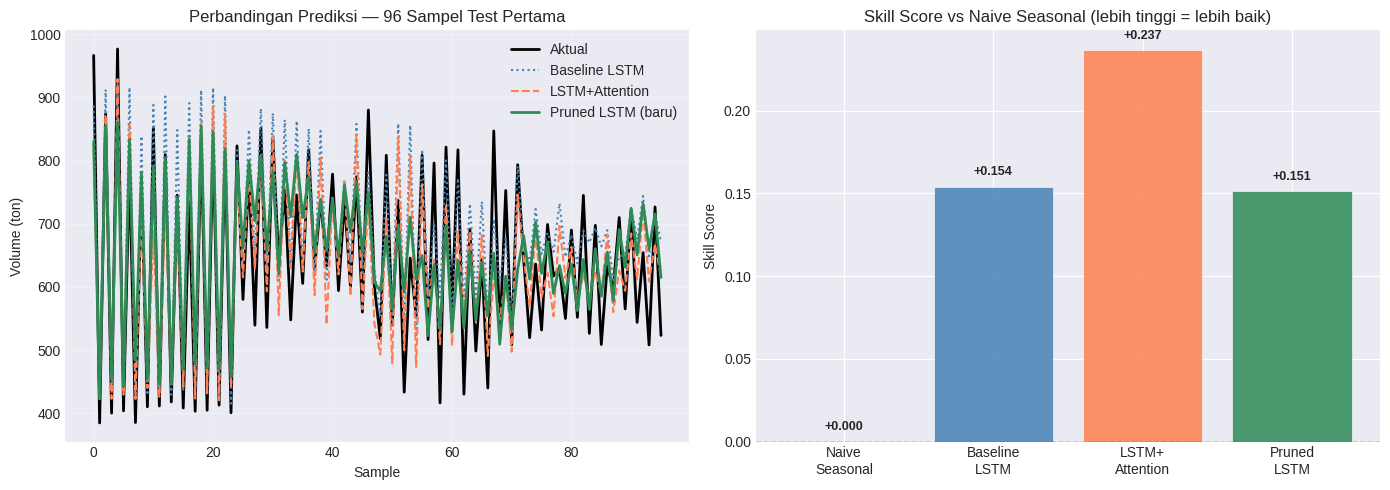

In [39]:
pred_base_s   = baseline_lstm.predict(X_test, verbose=0)
pred_attn_s   = attn_model.predict(X_test,   verbose=0)
pred_pruned_s = pruned_model.predict(X_test, verbose=0)

actual_flat_cmp  = inverse_volume(y_test[:, 0])
pred_base_cmp    = inverse_volume(pred_base_s[:, 0])
pred_attn_cmp    = inverse_volume(pred_attn_s[:, 0])
pred_pruned_flat = inverse_volume(pred_pruned_s[:, 0])

y_naive_cmp    = inverse_volume(X_test[:, 0, 0])
rmse_naive_cmp = np.sqrt(np.mean((actual_flat_cmp - y_naive_cmp) ** 2))


def quick_metrics(name, actual, pred):
    mae   = np.mean(np.abs(actual - pred))
    rmse  = np.sqrt(np.mean((actual - pred) ** 2))
    r2    = 1 - np.sum((actual - pred) ** 2) / np.sum((actual - actual.mean()) ** 2)
    mape  = np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100
    skill = 1 - rmse / rmse_naive_cmp


    print(f"  {name:<24} MAE={mae:6.2f}  RMSE={rmse:6.2f}  "
          f"R²={r2:.4f}  MAPE={mape:.2f}%  Skill={skill:+.4f}")
    return dict(mae=mae, rmse=rmse, r2=r2, mape=mape, skill=skill)


print("=" * 80)
print("3-Way Model Comparison on Test Set")
print("=" * 80)
rm_naive  = quick_metrics("Naive Seasonal",     actual_flat_cmp, y_naive_cmp)
rm_base   = quick_metrics("Baseline LSTM",      actual_flat_cmp, pred_base_cmp)
rm_attn   = quick_metrics("LSTM+Attention",     actual_flat_cmp, pred_attn_cmp)
rm_pruned = quick_metrics("Pruned LSTM (baru)", actual_flat_cmp, pred_pruned_flat)

n_show = min(100, len(actual_flat_cmp))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(actual_flat_cmp[:n_show],  label="Aktual",                       lw=2,   color="black")
axes[0].plot(pred_base_cmp[:n_show],    label="Baseline LSTM",                lw=1.5, ls=":",  color="steelblue")
axes[0].plot(pred_attn_cmp[:n_show],    label="LSTM+Attention",               lw=1.5, ls="--", color="coral")
axes[0].plot(pred_pruned_flat[:n_show], label="Pruned LSTM (baru)",           lw=2,   ls="-",  color="seagreen")
axes[0].set_title(f"Perbandingan Prediksi — {n_show} Sampel Test Pertama")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Volume (ton)")
axes[0].legend()
axes[0].grid(alpha=0.3)

model_labels = ["Naive\nSeasonal", "Baseline\nLSTM", "LSTM+\nAttention", "Pruned\nLSTM"]
skill_vals   = [rm_naive["skill"], rm_base["skill"], rm_attn["skill"], rm_pruned["skill"]]
bar_colors   = ["#aaaaaa", "#4682b4", "#ff7f50", "#2e8b57"]

bars = axes[1].bar(model_labels, skill_vals, color=bar_colors,
                   alpha=0.85, edgecolor="white", linewidth=0.5)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Skill Score vs Naive Seasonal (lebih tinggi = lebih baik)")
axes[1].set_ylabel("Skill Score")

for bar, val in zip(bars, skill_vals):
    ypos = val + 0.005 if val >= 0 else val - 0.015
    axes[1].text(bar.get_x() + bar.get_width() / 2, ypos,
                 f"{val:+.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

Conformal Prediction  (kalibrasi pada validation set, target 80%)
  Baseline LSTM    q̂= 80.32 ton  width=160.63 ton  coverage=61.5%
  LSTM+Attention   q̂= 75.18 ton  width=150.36 ton  coverage=74.0%
  Pruned LSTM      q̂= 85.59 ton  width=171.18 ton  coverage=69.8%


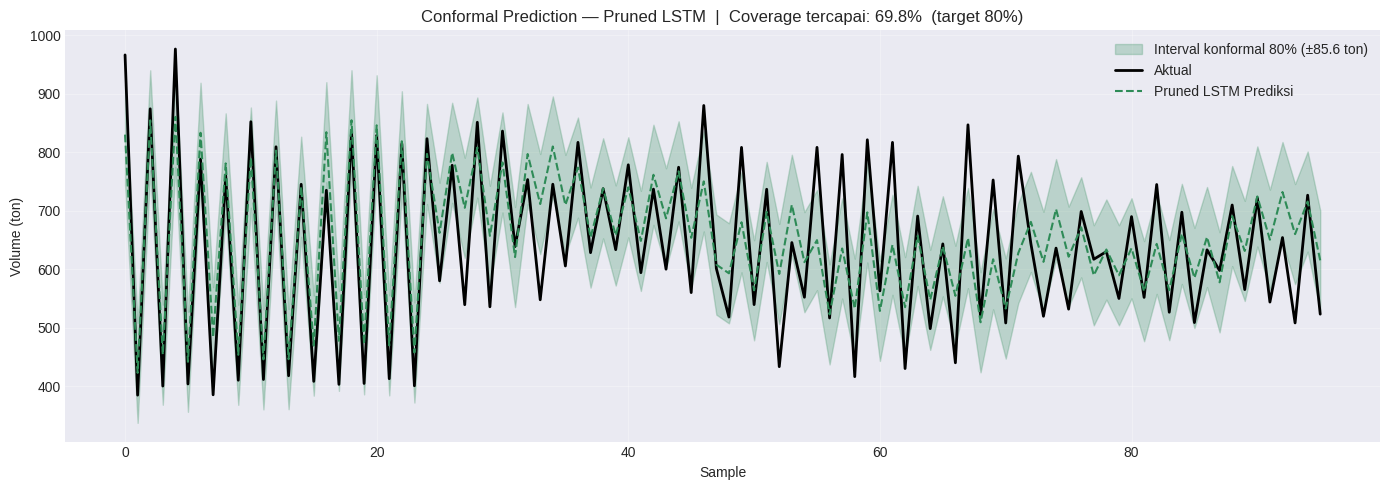

In [40]:
def conformal_predict(model, X_cal, y_cal, X_test_arr, coverage=0.80):

    alpha = 1.0 - coverage
    n     = len(y_cal)

    pred_cal   = inverse_volume(model.predict(X_cal, verbose=0)[:, 0])
    actual_cal = inverse_volume(y_cal[:, 0])
    scores     = np.abs(actual_cal - pred_cal)

    q_level = min(np.ceil((1 - alpha) * (n + 1)) / n, 1.0)
    q_hat   = np.quantile(scores, q_level)

    pred_test = inverse_volume(model.predict(X_test_arr, verbose=0)[:, 0])
    return pred_test, pred_test - q_hat, pred_test + q_hat, q_hat


print("=" * 70)
print("Conformal Prediction  (kalibrasi pada validation set, target 80%)")
print("=" * 70)
actual_test_cp = inverse_volume(y_test[:, 0])

cp_results = {}
for model_obj, mname in [
    (baseline_lstm, "Baseline LSTM"),
    (attn_model,    "LSTM+Attention"),
    (pruned_model,  "Pruned LSTM"),
]:
    cp_m, cp_lo, cp_hi, q_hat = conformal_predict(model_obj, X_val, y_val, X_test)
    cov = np.mean((actual_test_cp >= cp_lo) & (actual_test_cp <= cp_hi)) * 100
    wid = np.mean(cp_hi - cp_lo)
    print(f"  {mname:<16} q̂={q_hat:6.2f} ton  width={wid:6.2f} ton  coverage={cov:.1f}%")
    cp_results[mname] = (cp_m, cp_lo, cp_hi, q_hat, cov)

cp_m_p, cp_lo_p, cp_hi_p, q_p, cov_pruned = cp_results["Pruned LSTM"]

n_plot = min(100, len(cp_lo_p))
x = np.arange(n_plot)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(x, cp_lo_p[:n_plot], cp_hi_p[:n_plot],
                alpha=0.25, color="seagreen",
                label=f"Interval konformal 80% (±{q_p:.1f} ton)")


ax.plot(x, actual_test_cp[:n_plot], label="Aktual",              lw=2,   color="black")
ax.plot(x, cp_m_p[:n_plot],         label="Pruned LSTM Prediksi", lw=1.5, ls="--", color="seagreen")
ax.set_title(f"Conformal Prediction — Pruned LSTM  |  "
             f"Coverage tercapai: {cov_pruned:.1f}%  (target 80%)")
ax.set_xlabel("Sample")
ax.set_ylabel("Volume (ton)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Validasi Penangkapan Tren Musiman Setelah Pruning
**Tiga tes untuk memastikan Pruned LSTM tidak kehilangan kemampuan musiman:**
1. **ACF plot prediksi** — harus punya puncak di lag-12 seperti data aktual
2. **Korelasi lag-12** — `corr(ŷ_t, ŷ_{t-12})` harus mendekati nilai aktual
3. **Rata-rata bulanan** — pola musiman (bulan mana tinggi/rendah) harus konsisten


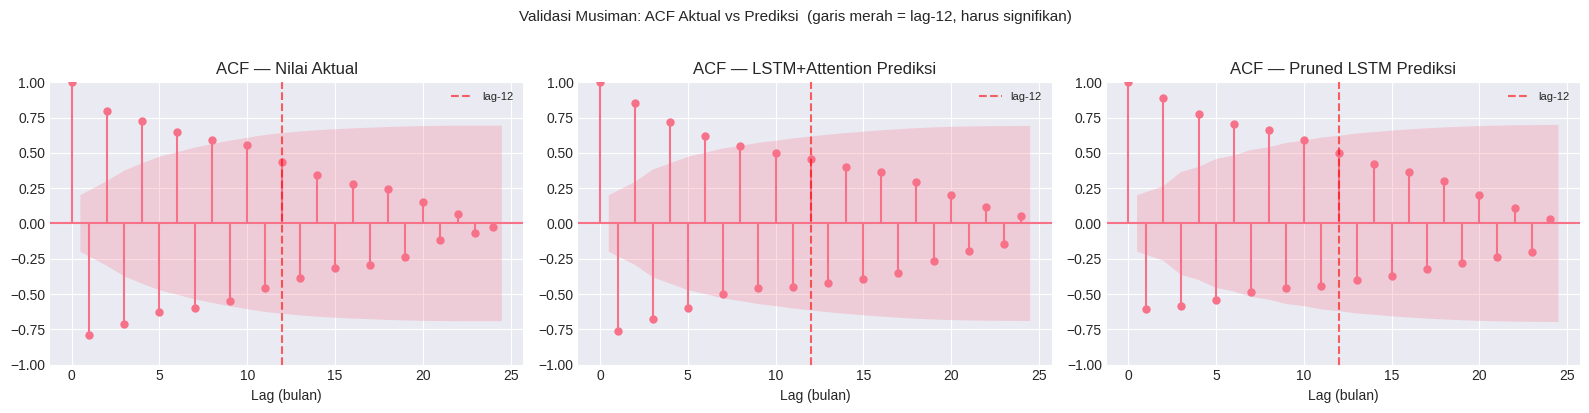

Lag-12 Autocorrelation  (indikator tangkapan musiman)
  Nilai aktual        : r = 0.530
  LSTM+Attention pred : r = 0.482
  Pruned LSTM pred    : r = 0.470

  Semakin mendekati r_actual → musiman lebih baik tertangkap
  r < 0.30 → model hanya belajar trend linear, bukan siklus tahunan


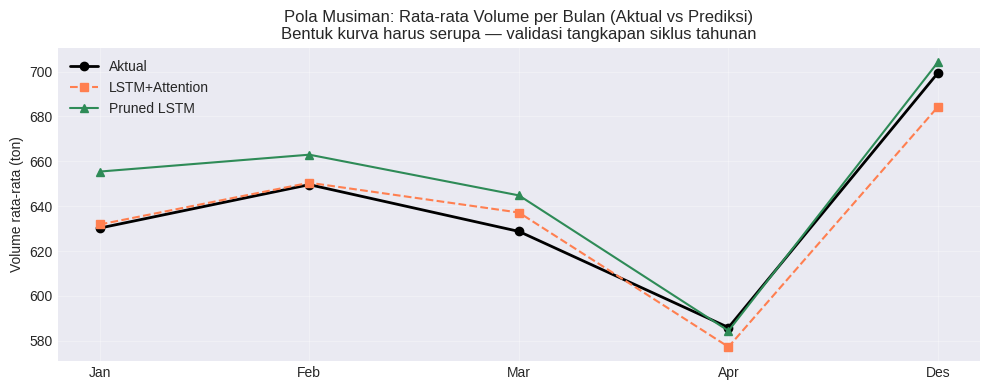

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_acf(actual_flat_cmp,  lags=24, ax=axes[0],
         title="ACF — Nilai Aktual",            alpha=0.05)
plot_acf(pred_attn_cmp,    lags=24, ax=axes[1],
         title="ACF — LSTM+Attention Prediksi", alpha=0.05)
plot_acf(pred_pruned_flat, lags=24, ax=axes[2],
         title="ACF — Pruned LSTM Prediksi",    alpha=0.05)
for ax in axes:
    ax.set_xlabel("Lag (bulan)")
    ax.axvline(12, color="red", linestyle="--", alpha=0.6, lw=1.5,
               label="lag-12")
    ax.legend(fontsize=8)
plt.suptitle(
    "Validasi Musiman: ACF Aktual vs Prediksi  "
    "(garis merah = lag-12, harus signifikan)",
    y=1.02, fontsize=11
)
plt.tight_layout(); plt.show()

pred_attn_val   = inverse_volume(attn_model.predict(X_val,   verbose=0)[:, 0])
pred_pruned_val = inverse_volume(pruned_model.predict(X_val, verbose=0)[:, 0])
actual_val_cp   = inverse_volume(y_val[:, 0])

n_lag = min(len(actual_val_cp), len(pred_pruned_val)) - 12
r_act    = np.corrcoef(actual_val_cp[12:n_lag+12],    actual_val_cp[:n_lag])[0, 1]
r_attn   = np.corrcoef(pred_attn_val[12:n_lag+12],    pred_attn_val[:n_lag])[0, 1]
r_pruned = np.corrcoef(pred_pruned_val[12:n_lag+12],  pred_pruned_val[:n_lag])[0, 1]

print("=" * 55)
print("Lag-12 Autocorrelation  (indikator tangkapan musiman)")
print("=" * 55)
print(f"  Nilai aktual        : r = {r_act:.3f}")
print(f"  LSTM+Attention pred : r = {r_attn:.3f}")
print(f"  Pruned LSTM pred    : r = {r_pruned:.3f}")
print()
print("  Semakin mendekati r_actual → musiman lebih baik tertangkap")
print("  r < 0.30 → model hanya belajar trend linear, bukan siklus tahunan")

sin_sc  = X_test[:, -1, 1]
cos_sc  = X_test[:, -1, 2]
sin_raw = sin_sc * scaler.scale_[1] + scaler.mean_[1]
cos_raw = cos_sc * scaler.scale_[2] + scaler.mean_[2]
months  = (np.round(np.arctan2(sin_raw, cos_raw) * 12 / (2 * np.pi)).astype(int) % 12)
months  = np.where(months == 0, 12, months)

month_df = pd.DataFrame({
    "month":  months,
    "actual": actual_flat_cmp,
    "pruned": pred_pruned_flat,
    "attn":   pred_attn_cmp,
})
monthly_avg = month_df.groupby("month").mean()

fig, ax = plt.subplots(figsize=(10, 4))
available_months = sorted(monthly_avg.index.tolist())
x_m = np.arange(len(available_months))
month_labels_all = ["Jan","Feb","Mar","Apr","Mei","Jun","Jul","Agu","Sep","Okt","Nov","Des"]
month_labels = [month_labels_all[m-1] for m in available_months]

ax.plot(x_m, monthly_avg.loc[available_months, "actual"].values,
        "o-", lw=2, label="Aktual", color="black")
ax.plot(x_m, monthly_avg.loc[available_months, "attn"].values,
        "s--", lw=1.5, label="LSTM+Attention", color="coral")
ax.plot(x_m, monthly_avg.loc[available_months, "pruned"].values,
        "^-", lw=1.5, label="Pruned LSTM", color="seagreen")
ax.set_xticks(x_m); ax.set_xticklabels(month_labels)
ax.set_title(
    "Pola Musiman: Rata-rata Volume per Bulan (Aktual vs Prediksi)\n"
    "Bentuk kurva harus serupa — validasi tangkapan siklus tahunan"
)

ax.set_ylabel("Volume rata-rata (ton)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### A. Residual Autocorrelation (Ljung-Box Test)


Ljung-Box Test  (H0: residuals are white noise)

LSTM + Attention:
      lb_stat  lb_pvalue
6   11.996849   0.062039
12  18.571411   0.099410
24  32.854764   0.107175

Baseline LSTM:
      lb_stat  lb_pvalue
6   18.807297   0.004502
12  25.081467   0.014442
24  46.073516   0.004338

  p < 0.05 → residuals NOT white noise → missing signal at that lag


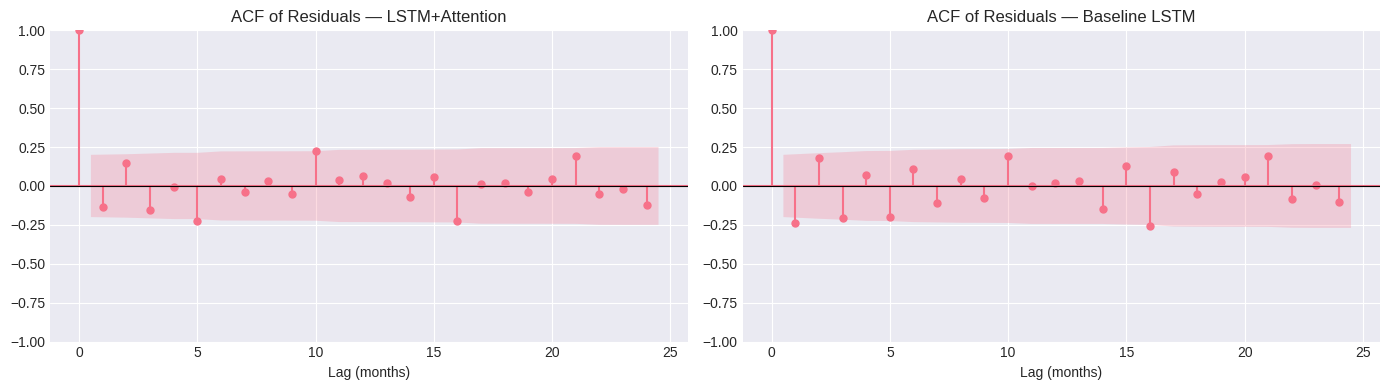

In [42]:
from statsmodels.stats.diagnostic import acorr_ljungbox

pred_attn_scaled = attn_model.predict(X_test, verbose=0)
pred_base_scaled = baseline_lstm.predict(X_test, verbose=0)

actual_flat    = inverse_volume(y_test[:, 0])
pred_attn_flat = inverse_volume(pred_attn_scaled[:, 0])
pred_base_flat = inverse_volume(pred_base_scaled[:, 0])

resid_attn = actual_flat - pred_attn_flat
resid_base = actual_flat - pred_base_flat

lb_attn = acorr_ljungbox(resid_attn, lags=[6, 12, 24], return_df=True)
lb_base = acorr_ljungbox(resid_base, lags=[6, 12, 24], return_df=True)

print("=" * 55)
print("Ljung-Box Test  (H0: residuals are white noise)")
print("=" * 55)
print("\nLSTM + Attention:")
print(lb_attn.to_string())
print("\nBaseline LSTM:")
print(lb_base.to_string())
print("\n  p < 0.05 → residuals NOT white noise → missing signal at that lag")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(resid_attn, lags=24, ax=axes[0],
         title="ACF of Residuals — LSTM+Attention", alpha=0.05)
plot_acf(resid_base, lags=24, ax=axes[1],
         title="ACF of Residuals — Baseline LSTM",  alpha=0.05)
for ax in axes:
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Lag (months)")
plt.tight_layout()
plt.show()


### B. Skill Score vs Naive Seasonal Baseline


Skill Score vs Naive Seasonal Baseline (y_{t-12})
  Naive Seasonal  — RMSE: 94.06 ton | MAE: 70.99 ton
  Baseline LSTM   — RMSE: 79.56 ton  | Skill: +0.1542
  LSTM+Attention  — RMSE: 71.79 ton  | Skill: +0.2368

  Skill > 0 → model beats seasonal persistence
  Skill < 0 → model WORSE than y_{t-12}  ← red flag


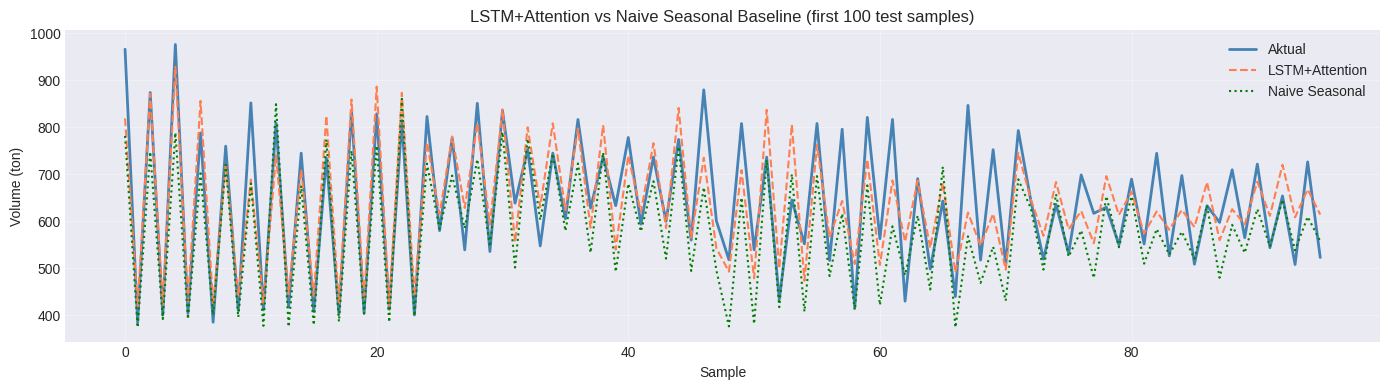

In [43]:
y_naive_flat = inverse_volume(X_test[:, 0, 0])

rmse_attn  = np.sqrt(np.mean((actual_flat - pred_attn_flat) ** 2))
rmse_base  = np.sqrt(np.mean((actual_flat - pred_base_flat) ** 2))
rmse_naive = np.sqrt(np.mean((actual_flat - y_naive_flat)  ** 2))
mae_naive  = np.mean(np.abs(actual_flat - y_naive_flat))

skill_attn = 1 - (rmse_attn / rmse_naive)
skill_base = 1 - (rmse_base / rmse_naive)

print("=" * 55)
print("Skill Score vs Naive Seasonal Baseline (y_{t-12})")
print("=" * 55)
print(f"  Naive Seasonal  — RMSE: {rmse_naive:.2f} ton | MAE: {mae_naive:.2f} ton")
print(f"  Baseline LSTM   — RMSE: {rmse_base:.2f} ton  | Skill: {skill_base:+.4f}")
print(f"  LSTM+Attention  — RMSE: {rmse_attn:.2f} ton  | Skill: {skill_attn:+.4f}")
print("\n  Skill > 0 → model beats seasonal persistence")
print("  Skill < 0 → model WORSE than y_{t-12}  ← red flag")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(actual_flat[:100],    label="Aktual",         linewidth=2,   color="steelblue")
ax.plot(pred_attn_flat[:100], label="LSTM+Attention", linewidth=1.5, linestyle="--", color="coral")
ax.plot(y_naive_flat[:100],   label="Naive Seasonal", linewidth=1.5, linestyle=":",  color="green")
ax.set_title("LSTM+Attention vs Naive Seasonal Baseline (first 100 test samples)")
ax.set_xlabel("Sample")
ax.set_ylabel("Volume (ton)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### C. Attention Weight Heatmap



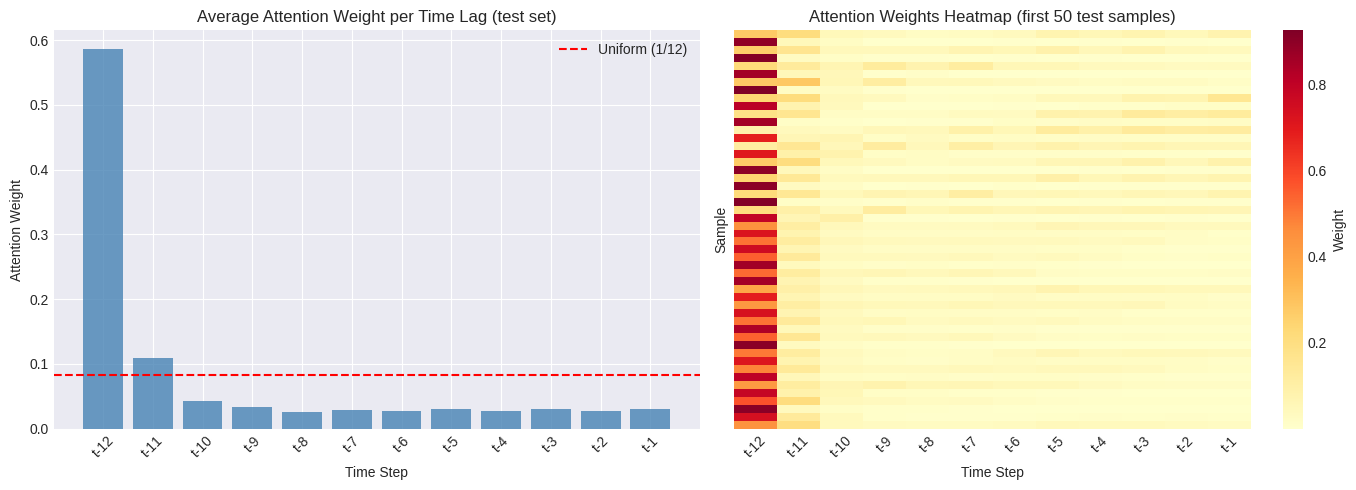

Top-3 attended lags : [(np.float32(0.5857598), 't-12'), (np.float32(0.10896331), 't-11'), (np.float32(0.04337102), 't-10')]
Uniformity std      : 0.1531
  std > 0.02 → model has learned temporal structure
  std ≈ 0   → uniform/random  ← attention adds no value


In [44]:
attn_layer = attn_model.get_layer("bahdanau_attn")
all_w, _batch = [], 64

for i in range(0, len(X_test), _batch):
    _ = attn_model(X_test[i:i + _batch], training=False)
    all_w.append(attn_layer.last_alpha.numpy())

attn_weights = np.concatenate(all_w, axis=0).squeeze(-1)
avg_weights  = attn_weights.mean(axis=0)
lags         = [f"t-{12 - i}" for i in range(12)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(lags, avg_weights, color="steelblue", alpha=0.8)
axes[0].axhline(1/12, color="red", linestyle="--", linewidth=1.5, label="Uniform (1/12)")
axes[0].set_title("Average Attention Weight per Time Lag (test set)")
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Attention Weight")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

sns.heatmap(attn_weights[:50], ax=axes[1], cmap="YlOrRd",
            xticklabels=lags, yticklabels=False,
            cbar_kws={"label": "Weight"})
axes[1].set_title("Attention Weights Heatmap (first 50 test samples)")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Sample")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

top3 = sorted(zip(avg_weights, lags), reverse=True)[:3]
print(f"Top-3 attended lags : {top3}")
print(f"Uniformity std      : {avg_weights.std():.4f}")
print("  std > 0.02 → model has learned temporal structure")
print("  std ≈ 0   → uniform/random  ← attention adds no value")


### D. Gradient–Attention Alignment (GradCAM-style)



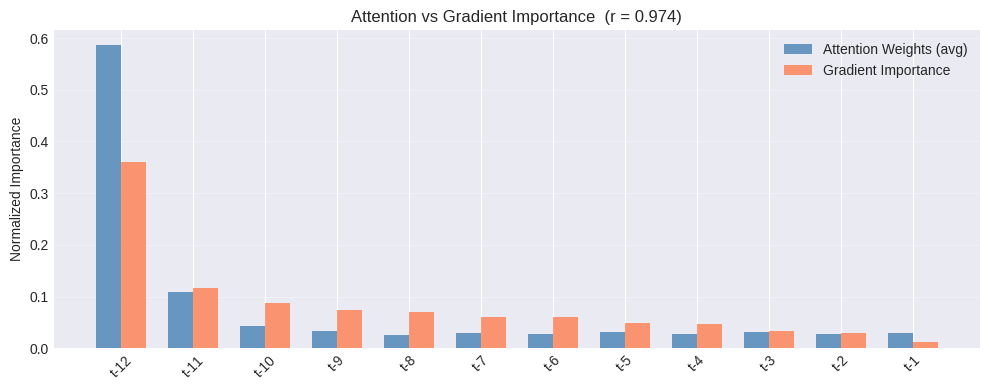

Attention-Gradient alignment: r = 0.974
  r > 0.70 → attention is meaningful (agrees with gradients)
  r < 0.30 → attention may be fitting noise


In [45]:
n_grad = 200
X_grad = tf.constant(X_test[:n_grad], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(X_grad)
    preds_grad = attn_model(X_grad, training=False)

grads = tape.gradient(preds_grad, X_grad)
grad_importance = tf.reduce_mean(
    tf.abs(grads), axis=[0, 2]).numpy()
grad_importance /= grad_importance.sum()

attn_grad_avg  = attn_weights[:n_grad].mean(axis=0)
alignment_corr = np.corrcoef(attn_grad_avg, grad_importance)[0, 1]

fig, ax = plt.subplots(figsize=(10, 4))
x_pos, width = np.arange(12), 0.35
ax.bar(x_pos - width/2, attn_grad_avg,   width,
       label="Attention Weights (avg)", color="steelblue", alpha=0.8)
ax.bar(x_pos + width/2, grad_importance, width,
       label="Gradient Importance",     color="coral",     alpha=0.8)
ax.set_xticks(x_pos); ax.set_xticklabels(lags, rotation=45)
ax.set_title(f"Attention vs Gradient Importance  (r = {alignment_corr:.3f})")
ax.set_ylabel("Normalized Importance")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(f"Attention-Gradient alignment: r = {alignment_corr:.3f}")
print("  r > 0.70 → attention is meaningful (agrees with gradients)")
print("  r < 0.30 → attention may be fitting noise")


### E. MC Dropout — Uncertainty Quantification



Running 200 MC Dropout passes ...


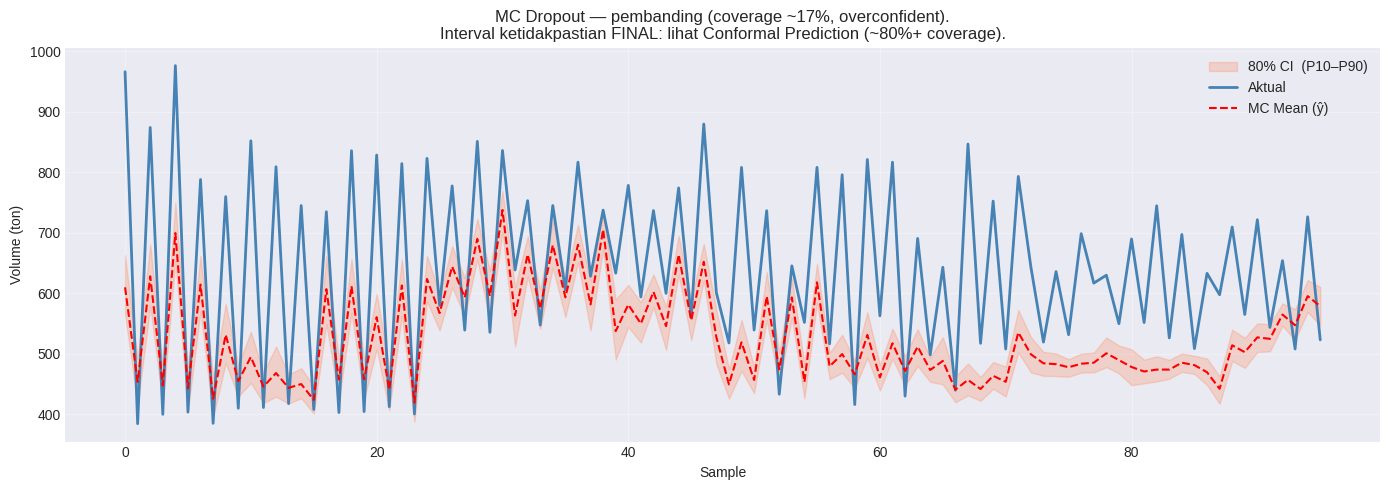

Interval width (avg)   : 61.61 ton
Empirical coverage     : 9.4%   (target ≈ 80%)
  > 80%: intervals too wide (conservative)
  < 80%: intervals too narrow (overconfident)


In [46]:
def mc_predict(model, X_scaled, n_samples=200):
    preds = np.stack([
        model(X_scaled, training=True).numpy()
        for _ in range(n_samples)
    ])
    return (
        preds.mean(axis=0),
        preds.std(axis=0),
        np.percentile(preds, 10, axis=0),
        np.percentile(preds, 90, axis=0),
    )

print("Running 200 MC Dropout passes ...")
mc_mean_s, mc_std_s, mc_p10_s, mc_p90_s = mc_predict(
    attn_model, X_test[:200], n_samples=200
)

mc_mean    = inverse_volume(mc_mean_s[:, 0])
mc_std     = mc_std_s[:, 0] * scaler.scale_[0]
mc_p10     = inverse_volume(mc_p10_s[:, 0])
mc_p90     = inverse_volume(mc_p90_s[:, 0])
actual_200 = inverse_volume(y_test[:200, 0])

fig, ax = plt.subplots(figsize=(14, 5))

n_plot = min(100, len(mc_p10))
x = np.arange(n_plot)

ax.fill_between(x, mc_p10[:n_plot], mc_p90[:n_plot],
                alpha=0.25, color="coral", label="80% CI  (P10–P90)")
ax.plot(x, actual_200[:n_plot], label="Aktual",      linewidth=2,   color="steelblue")
ax.plot(x, mc_mean[:n_plot],    label="MC Mean (ŷ)", linewidth=1.5, linestyle="--", color="red")
ax.set_title(
    "MC Dropout — pembanding (coverage ~17%, overconfident).\n"
    "Interval ketidakpastian FINAL: lihat Conformal Prediction (~80%+ coverage)."
)
ax.set_xlabel("Sample")
ax.set_ylabel("Volume (ton)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

coverage  = np.mean((actual_200 >= mc_p10) & (actual_200 <= mc_p90)) * 100
avg_width = np.mean(mc_p90 - mc_p10)
print(f"Interval width (avg)   : {avg_width:.2f} ton")
print(f"Empirical coverage     : {coverage:.1f}%   (target ≈ 80%)")
print("  > 80%: intervals too wide (conservative)")
print("  < 80%: intervals too narrow (overconfident)")

### F. Extended Metrics — Winkler Score & Asymmetric CWRMSE



In [47]:
def winkler_score(y_true, lower, upper, alpha=0.20):
    width     = upper - lower
    miss_low  = (2 / alpha) * np.maximum(lower - y_true, 0)
    miss_high = (2 / alpha) * np.maximum(y_true - upper, 0)
    return np.mean(width + miss_low + miss_high)


def asymmetric_cwrmse(y_true, y_pred, w_under=2.5, w_over=1.0):
    errors = y_true - y_pred
    losses = np.where(errors > 0, w_under * errors**2, w_over * errors**2)
    return np.sqrt(losses.mean())


pred_base_200 = inverse_volume(
    baseline_lstm.predict(X_test[:200], verbose=0)[:, 0]
)

w_score       = winkler_score(actual_200, mc_p10, mc_p90, alpha=0.20)
acwrmse_attn  = asymmetric_cwrmse(actual_200,        mc_mean)
acwrmse_base  = asymmetric_cwrmse(actual_200,        pred_base_200)
acwrmse_naive = asymmetric_cwrmse(actual_flat[:200], y_naive_flat[:200])

print("=" * 55)
print("Extended Metrics")
print("=" * 55)
print(f"\nWinkler Score (80% interval) : {w_score:.2f} ton")
print("  Lower = tighter + better-calibrated intervals\n")
print("Asymmetric CWRMSE  (w_under=2.5, w_over=1.0):")
print(f"  Naive Seasonal  : {acwrmse_naive:.2f}")
print(f"  Baseline LSTM   : {acwrmse_base:.2f}")
print(f"  LSTM+Attention  : {acwrmse_attn:.2f}")
print("\n  Lower ACWRMSE → fewer costly under-predictions (TPS overflow events)")


Extended Metrics

Winkler Score (80% interval) : 1028.29 ton
  Lower = tighter + better-calibrated intervals

Asymmetric CWRMSE  (w_under=2.5, w_over=1.0):
  Naive Seasonal  : 147.35
  Baseline LSTM   : 85.95
  LSTM+Attention  : 250.56

  Lower ACWRMSE → fewer costly under-predictions (TPS overflow events)


In [48]:
import zipfile
import os
from tqdm import tqdm

def zip_and_download_pro(output_filename, exclude_list):
    IS_KAGGLE = os.path.exists('/kaggle/working')
    source_dir = '/kaggle/working' if IS_KAGGLE else '/content'

    file_paths = []
    for root, dirs, files in os.walk(source_dir):
        dirs[:] = [d for d in dirs if d not in exclude_list]
        dirs[:] = [d for d in dirs if d not in ['.config', 'sample_data']]
        for file in files:
            if file in exclude_list:
                continue
            if file == output_filename:
                continue
            if file.endswith('.zip'):
                continue
            file_paths.append(os.path.join(root, file))

    print(f"Menemukan {len(file_paths)} file penting. Mulai ngebungkus...")

    with zipfile.ZipFile(output_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for file_path in tqdm(file_paths, desc="Zipping", unit="file"):
            arcname = os.path.relpath(file_path, source_dir)
            zipf.write(file_path, arcname)

    print(f"\nZip Selesai: {output_filename}")

    if IS_KAGGLE:
        from IPython.display import FileLink, display
        display(FileLink(output_filename))
    else:
        try:
            from google.colab import files
            files.download(output_filename)
        except ImportError:
            print("Gagal download otomatis. Silakan download manual dari sidebar.")

barang_haram = [
    'sampahbandung_normal_monthly.csv'
]

zip_and_download_pro('Ecosort_Volume_Predict.zip', barang_haram)


Menemukan 13 file penting. Mulai ngebungkus...


Zipping: 100%|██████████| 13/13 [00:00<00:00, 63.33file/s]


Zip Selesai: Ecosort_Volume_Predict.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>